This notebook implements a leakage-controlled machine learning framework
for CRM lead-conversion prediction.

The framework evaluates 11 classical machine learning algorithms across
multiple model families and incorporates:

- Stratified train-test splitting
- Training-fold-only preprocessing
- Feature scaling
- One-hot encoding
- Principal Component Analysis (PCA)
- Class-imbalance treatment using SMOTE
- Cross-validated hyperparameter optimization
- Comprehensive model evaluation
- Precision-Recall analysis
- Statistical comparison
- Explainable AI using SHAP and LIME
- Robustness analysis across alternative imbalance strategies

The 30% test set is isolated before model development and is reserved
exclusively for final out-of-sample evaluation.

In [1]:
pip install Jinja2

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade --force-reinstall pyzmq

  Using cached pyzmq-27.2.0-cp312-abi3-win_amd64.whl.metadata (3.8 kB)
Using cached pyzmq-27.2.0-cp312-abi3-win_amd64.whl (628 kB)
  Attempting uninstall: pyzmq
    Found existing installation: pyzmq 27.2.0
    Uninstalling pyzmq-27.2.0:
      Successfully uninstalled pyzmq-27.2.0
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


In [3]:
pip install --upgrade pip setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import (
    SMOTE,
    ADASYN,
    RandomOverSampler
)

from imblearn.under_sampling import (
    RandomUnderSampler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from statsmodels.stats.contingency_tables import mcnemar

import shap
from lime.lime_tabular import LimeTabularExplainer

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

RANDOM_STATE = 42

TEST_SIZE = 0.30

N_SPLITS = 5

PCA_VARIANCE = 0.95

# Change this to your actual dataset location
DATA_PATH = r"C:\Users\dchauhan\OneDrive - Gartner, Inc\Documents\Desktop\ThesisPrep\KaggleDataset\Leads.csv"

# Output folder
OUTPUT_DIR = r"C:\Users\dchauhan\OneDrive - Gartner, Inc\Documents\Desktop\ThesisPrep\Thesis_Corrected_Results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Random state:", RANDOM_STATE)
print("Test size:", TEST_SIZE)
print("Cross-validation folds:", N_SPLITS)
print("PCA variance threshold:", PCA_VARIANCE)

Output directory: C:\Users\dchauhan\OneDrive - Gartner, Inc\Documents\Desktop\ThesisPrep\Thesis_Corrected_Results
Random state: 42
Test size: 0.3
Cross-validation folds: 5
PCA variance threshold: 0.95


In [7]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (9240, 37)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified



Column names:
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


In [8]:
# ============================================================
# INITIAL DATA INSPECTION
# ============================================================

print("Dataset dimensions:")
print(df.shape)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (
        missing / len(df) * 100
    )
})

display(
    missing_table[
        missing_table["Missing_Count"] > 0
    ].sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

Dataset dimensions:
(9240, 37)

Data types:


Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                            object
Magazine                       


Missing values:


,Missing_Count,Missing_Percentage
Lead Quality,4767,51.590909
Asymmetrique Profile Score,4218,45.649351
Asymmetrique Activity Index,4218,45.649351
Asymmetrique Activity Score,4218,45.649351
Asymmetrique Profile Index,4218,45.649351
Tags,3353,36.287879
What matters most to you in choosing a course,2709,29.318182
Lead Profile,2709,29.318182
What is your current occupation,2690,29.112554
Country,2461,26.634199


In [9]:
# ============================================================
# REMOVE IDENTIFIER VARIABLES
# ============================================================

identifier_columns = [
    "Prospect ID",
    "Lead Number"
]

identifier_columns = [
    col for col in identifier_columns
    if col in df.columns
]

df = df.drop(
    columns=identifier_columns
)

print("Removed identifier columns:")
print(identifier_columns)

print("\nNew dataset shape:", df.shape)

Removed identifier columns:
['Prospect ID', 'Lead Number']

New dataset shape: (9240, 35)


In [10]:
# ============================================================
# TARGET VARIABLE
# ============================================================

TARGET = "Converted"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found."
    )

# Remove rows with missing target
df = df.dropna(
    subset=[TARGET]
).copy()

print("Target values before conversion:")
print(df[TARGET].value_counts(dropna=False))


# ------------------------------------------------------------
# Convert target to binary
# ------------------------------------------------------------

if df[TARGET].dtype == "object":

    target_mapping = {
        "Yes": 1,
        "No": 0,
        "yes": 1,
        "no": 0,
        "Converted": 1,
        "Not Converted": 0
    }

    df[TARGET] = df[TARGET].map(
        target_mapping
    )

    if df[TARGET].isna().any():

        unique_values = (
            df[TARGET]
            .dropna()
            .unique()
        )

        raise ValueError(
            f"Unrecognised target values found: {unique_values}"
        )


df[TARGET] = df[TARGET].astype(int)

X = df.drop(
    columns=[TARGET]
)

y = df[TARGET]


print("\nTarget distribution:")
display(
    y.value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

print("\nTarget proportions:")
display(
    y.value_counts(
        normalize=True
    )
    .rename_axis("Class")
    .reset_index(name="Proportion")
)

Target values before conversion:
Converted
0    5679
1    3561
Name: count, dtype: int64

Target distribution:


,Class,Count
0,0,5679
1,1,3561



Target proportions:


,Class,Proportion
0,0,0.61461
1,1,0.38539


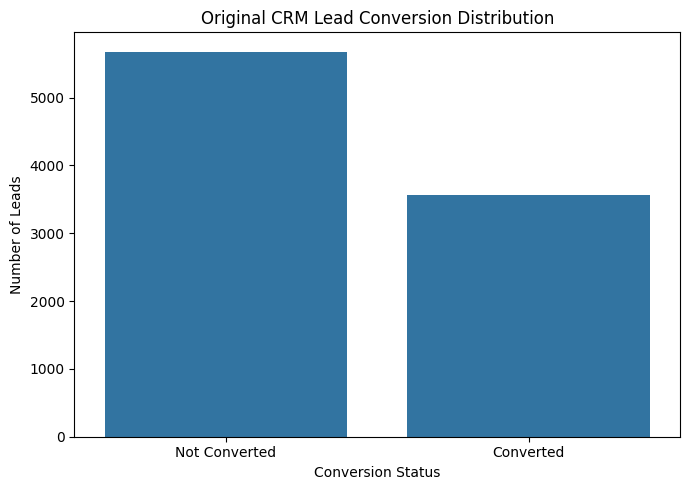

In [11]:
# ============================================================
# ORIGINAL CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y
)

plt.title(
    "Original CRM Lead Conversion Distribution"
)

plt.xlabel(
    "Conversion Status"
)

plt.ylabel(
    "Number of Leads"
)

plt.xticks(
    [0, 1],
    ["Not Converted", "Converted"]
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_Original_Class_Distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# FEATURE TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print("\nNumerical variables:")
print(numeric_features)

print("\nCategorical variables:")
print(categorical_features)

Numerical features: 5
Categorical features: 29

Numerical variables:
['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

Categorical variables:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']


In [13]:
# ============================================================
# STRATIFIED 70/30 TRAIN-TEST SPLIT
# ============================================================
#
# IMPORTANT:
# The test set is isolated BEFORE:
#
# - imputation
# - encoding
# - scaling
# - PCA
# - SMOTE
# - hyperparameter tuning
# - model fitting
#
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("TRAINING SET")
print("------------")
print("Observations:", len(X_train))

print("\nTEST SET")
print("--------")
print("Observations:", len(X_test))

print("\nTraining class distribution:")
display(
    y_train.value_counts()
)

print("\nTesting class distribution:")
display(
    y_test.value_counts()
)

TRAINING SET
------------
Observations: 6468

TEST SET
--------
Observations: 2772

Training class distribution:


Converted
0    3975
1    2493
Name: count, dtype: int64


Testing class distribution:


Converted
0    1704
1    1068
Name: count, dtype: int64

In [14]:
# ============================================================
# PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [15]:
# ============================================================
# STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(
    f"{N_SPLITS}-fold Stratified Cross-Validation configured."
)

5-fold Stratified Cross-Validation configured.


In [16]:
# ============================================================
# 11 CLASSICAL MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ),

    "Gaussian Naive Bayes":
        GaussianNB(),

    "KNN":
        KNeighborsClassifier(
            n_jobs=-1
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=RANDOM_STATE
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=RANDOM_STATE
        ),

    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
}

print(
    f"{len(models)} models configured."
)

for i, name in enumerate(
    models.keys(),
    start=1
):
    print(f"{i}. {name}")

11 models configured.
1. Logistic Regression
2. Gaussian Naive Bayes
3. KNN
4. SVM
5. Decision Tree
6. Extra Trees
7. Random Forest
8. Gradient Boosting
9. AdaBoost
10. HistGradientBoosting
11. XGBoost


In [17]:
# ============================================================
# HYPERPARAMETER GRIDS
# ============================================================

param_grids = {

    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs"]
    },


    "Gaussian Naive Bayes": {
        "model__var_smoothing": [
            1e-11,
            1e-9,
            1e-7
        ]
    },


    "KNN": {
        "model__n_neighbors": [
            5,
            11,
            21
        ],
        "model__weights": [
            "uniform",
            "distance"
        ],
        "model__p": [
            1,
            2
        ]
    },


    "SVM": {
        "model__C": [
            0.1,
            1,
            10
        ],
        "model__kernel": [
            "rbf",
            "linear"
        ],
        "model__gamma": [
            "scale",
            "auto"
        ]
    },


    "Decision Tree": {
        "model__max_depth": [
            None,
            5,
            10,
            20
        ],
        "model__min_samples_split": [
            2,
            5,
            10
        ],
        "model__min_samples_leaf": [
            1,
            2,
            5
        ]
    },


    "Extra Trees": {
        "model__n_estimators": [
            100,
            200
        ],
        "model__max_depth": [
            None,
            10,
            20
        ],
        "model__min_samples_leaf": [
            1,
            2
        ],
        "model__max_features": [
            "sqrt",
            "log2"
        ]
    },


    "Random Forest": {
        "model__n_estimators": [
            100,
            200
        ],
        "model__max_depth": [
            None,
            10,
            20
        ],
        "model__min_samples_split": [
            2,
            5
        ],
        "model__min_samples_leaf": [
            1,
            2
        ],
        "model__max_features": [
            "sqrt",
            "log2"
        ]
    },


    "Gradient Boosting": {
        "model__n_estimators": [
            100,
            200
        ],
        "model__learning_rate": [
            0.05,
            0.1
        ],
        "model__max_depth": [
            2,
            3
        ],
        "model__subsample": [
            0.8,
            1.0
        ]
    },


    "AdaBoost": {
        "model__n_estimators": [
            100,
            200
        ],
        "model__learning_rate": [
            0.05,
            0.1,
            0.5,
            1.0
        ]
    },


    "HistGradientBoosting": {
        "model__max_iter": [
            100,
            200
        ],
        "model__learning_rate": [
            0.05,
            0.1
        ],
        "model__max_leaf_nodes": [
            15,
            31
        ],
        "model__l2_regularization": [
            0,
            1
        ]
    },


    "XGBoost": {
        "model__n_estimators": [
            100,
            200
        ],
        "model__max_depth": [
            3,
            5
        ],
        "model__learning_rate": [
            0.05,
            0.1
        ],
        "model__subsample": [
            0.8,
            1.0
        ],
        "model__colsample_bytree": [
            0.8,
            1.0
        ]
    }
}

print("Hyperparameter grids configured.")

Hyperparameter grids configured.


In [18]:
# ============================================================
# LEAKAGE-CONTROLLED PIPELINES
# ============================================================
#
# Pipeline order:
#
# Preprocessing
#      ↓
# PCA
#      ↓
# SMOTE
#      ↓
# Model
#
# GridSearchCV operates ONLY on X_train/y_train.
#
# Because SMOTE is inside an imblearn Pipeline, it is fitted
# separately within each training fold.
#
# ============================================================

pipelines = {}

for name, model in models.items():

    pipelines[name] = ImbPipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),

            (
                "pca",
                PCA(
                    n_components=PCA_VARIANCE,
                    random_state=RANDOM_STATE
                )
            ),

            (
                "smote",
                SMOTE(
                    random_state=RANDOM_STATE
                )
            ),

            (
                "model",
                model
            )
        ]
    )

print(
    "Leakage-controlled pipelines created."
)

Leakage-controlled pipelines created.


In [19]:
# ============================================================
# MODEL TRAINING + GRIDSEARCHCV
# ============================================================
#
# NOTE:
# This may take considerable time because 11 models are being
# optimized using 5-fold cross-validation.
#
# ============================================================

best_models = {}

grid_results = []

training_summary = []


for model_number, name in enumerate(
    pipelines.keys(),
    start=1
):

    print("\n" + "=" * 75)
    print(
        f"MODEL {model_number}/11: {name}"
    )
    print("=" * 75)

    pipeline = pipelines[name]

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=1
    )

    grid.fit(
        X_train,
        y_train
    )

    best_models[name] = (
        grid.best_estimator_
    )

    print("\nBest parameters:")
    print(grid.best_params_)

    print(
        "\nBest CV F1:",
        round(
            grid.best_score_,
            4
        )
    )

    training_summary.append({
        "Model": name,
        "Best_CV_F1": grid.best_score_,
        "Best_Parameters": str(
            grid.best_params_
        )
    })

    temp = pd.DataFrame(
        grid.cv_results_
    )

    temp["Model"] = name

    grid_results.append(
        temp
    )


training_summary_df = pd.DataFrame(
    training_summary
)

display(
    training_summary_df
)

training_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "01_CV_Training_Summary.csv"
    ),
    index=False
)

print("\nAll models trained.")


MODEL 1/11: Logistic Regression
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters:
{'model__C': 1, 'model__solver': 'lbfgs'}

Best CV F1: 0.8725

MODEL 2/11: Gaussian Naive Bayes
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters:
{'model__var_smoothing': 1e-11}

Best CV F1: 0.7691

MODEL 3/11: KNN
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters:
{'model__n_neighbors': 21, 'model__p': 1, 'model__weights': 'distance'}

Best CV F1: 0.8537

MODEL 4/11: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Best CV F1: 0.8887

MODEL 5/11: Decision Tree
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}

Best CV F1: 0.8025

MODEL 6/11: Extra Trees
Fitting 5 folds for each of 24 candidates, totalling 12

,Model,Best_CV_F1,Best_Parameters
0,Logistic Regression,0.872494,"{'model__C': 1, 'model__solver': 'lbfgs'}"
1,Gaussian Naive Bayes,0.769144,{'model__var_smoothing': 1e-11}
2,KNN,0.853651,"{'model__n_neighbors': 21, 'model__p': 1, 'mod..."
3,SVM,0.888732,"{'model__C': 1, 'model__gamma': 'scale', 'mode..."
4,Decision Tree,0.802548,"{'model__max_depth': 10, 'model__min_samples_l..."
5,Extra Trees,0.880310,"{'model__max_depth': 20, 'model__max_features'..."
6,Random Forest,0.883343,"{'model__max_depth': None, 'model__max_feature..."
7,Gradient Boosting,0.879224,"{'model__learning_rate': 0.1, 'model__max_dept..."
8,AdaBoost,0.866026,"{'model__learning_rate': 0.5, 'model__n_estima..."
9,HistGradientBoosting,0.890356,"{'model__l2_regularization': 1, 'model__learni..."



All models trained.


In [20]:
# ============================================================
# PCA COMPONENT INFORMATION
# ============================================================

pca_information = []

for name, pipeline in best_models.items():

    pca = pipeline.named_steps["pca"]

    pca_information.append({
        "Model": name,
        "Components": pca.n_components_,
        "Explained_Variance": (
            pca.explained_variance_ratio_.sum()
        )
    })


pca_df = pd.DataFrame(
    pca_information
)

display(
    pca_df
)

pca_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_PCA_Information.csv"
    ),
    index=False
)

,Model,Components,Explained_Variance
0,Logistic Regression,49,0.952199
1,Gaussian Naive Bayes,49,0.952199
2,KNN,49,0.952199
3,SVM,49,0.952199
4,Decision Tree,49,0.952199
5,Extra Trees,49,0.952199
6,Random Forest,49,0.952199
7,Gradient Boosting,49,0.952199
8,AdaBoost,49,0.952199
9,HistGradientBoosting,49,0.952199


In [21]:
# ============================================================
# FINAL TEST-SET EVALUATION
# ============================================================
#
# The test set is used ONLY NOW.
#
# No model, preprocessing step, PCA transformation, SMOTE
# operation or hyperparameter search is fitted using X_test.
#
# ============================================================

results = []

predictions = {}

probabilities = {}


for name, model in best_models.items():

    y_pred = model.predict(
        X_test
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob
        ),

        "PR_AUC": average_precision_score(
            y_test,
            y_prob
        )
    })


results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)


print(
    "FINAL TEST-SET PERFORMANCE"
)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)


results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "03_Final_Test_Set_Performance.csv"
    ),
    index=False
)

FINAL TEST-SET PERFORMANCE


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,HistGradientBoosting,0.9181,0.8926,0.8951,0.8939,0.9688,0.9537
1,XGBoost,0.9138,0.8849,0.8923,0.8886,0.9687,0.9536
2,Gradient Boosting,0.9123,0.8753,0.9007,0.8879,0.9651,0.9497
3,SVM,0.9149,0.8852,0.8951,0.8901,0.9647,0.9519
4,Extra Trees,0.9102,0.9027,0.8596,0.8806,0.9611,0.9400
5,AdaBoost,0.9012,0.8557,0.8942,0.8745,0.9604,0.9424
6,Random Forest,0.9044,0.8820,0.8680,0.8749,0.9603,0.9404
7,Logistic Regression,0.8997,0.8571,0.8876,0.8721,0.9531,0.9324
8,KNN,0.8820,0.8230,0.8839,0.8524,0.9466,0.9220
9,Decision Tree,0.8499,0.7958,0.8212,0.8083,0.8783,0.8045


In [22]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

for name in results_df["Model"]:

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "Not Converted",
                "Converted"
            ],
            zero_division=0
        )
    )


HistGradientBoosting
               precision    recall  f1-score   support

Not Converted       0.93      0.93      0.93      1704
    Converted       0.89      0.90      0.89      1068

     accuracy                           0.92      2772
    macro avg       0.91      0.91      0.91      2772
 weighted avg       0.92      0.92      0.92      2772


XGBoost
               precision    recall  f1-score   support

Not Converted       0.93      0.93      0.93      1704
    Converted       0.88      0.89      0.89      1068

     accuracy                           0.91      2772
    macro avg       0.91      0.91      0.91      2772
 weighted avg       0.91      0.91      0.91      2772


Gradient Boosting
               precision    recall  f1-score   support

Not Converted       0.94      0.92      0.93      1704
    Converted       0.88      0.90      0.89      1068

     accuracy                           0.91      2772
    macro avg       0.91      0.91      0.91      2772
 weight

In [23]:
# ============================================================
# MODEL RANKING
# ============================================================

ranking_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

ranking_df = results_df.copy()

for metric in ranking_metrics:

    ranking_df[
        metric + "_Rank"
    ] = ranking_df[
        metric
    ].rank(
        ascending=False,
        method="min"
    )


rank_columns = [
    metric + "_Rank"
    for metric in ranking_metrics
]

ranking_df["Mean_Rank"] = (
    ranking_df[rank_columns]
    .mean(axis=1)
)

ranking_df = ranking_df.sort_values(
    "Mean_Rank"
).reset_index(drop=True)

ranking_df[
    [
        "Model",
        "Accuracy_Rank",
        "Precision_Rank",
        "Recall_Rank",
        "F1_Rank",
        "ROC_AUC_Rank",
        "PR_AUC_Rank",
        "Mean_Rank"
    ]
]

,Model,Accuracy_Rank,Precision_Rank,Recall_Rank,F1_Rank,ROC_AUC_Rank,PR_AUC_Rank,Mean_Rank
0,HistGradientBoosting,1.0,2.0,2.0,1.0,1.0,1.0,1.333333
1,SVM,2.0,3.0,2.0,2.0,4.0,3.0,2.666667
2,XGBoost,3.0,4.0,5.0,3.0,2.0,2.0,3.166667
3,Gradient Boosting,4.0,6.0,1.0,4.0,3.0,4.0,3.666667
4,Extra Trees,5.0,1.0,9.0,5.0,5.0,7.0,5.333333
5,AdaBoost,7.0,8.0,4.0,7.0,6.0,5.0,6.166667
6,Random Forest,6.0,5.0,8.0,6.0,7.0,6.0,6.333333
7,Logistic Regression,8.0,7.0,6.0,8.0,8.0,8.0,7.500000
8,KNN,9.0,9.0,7.0,9.0,9.0,9.0,8.666667
9,Decision Tree,10.0,10.0,11.0,10.0,10.0,11.0,10.333333


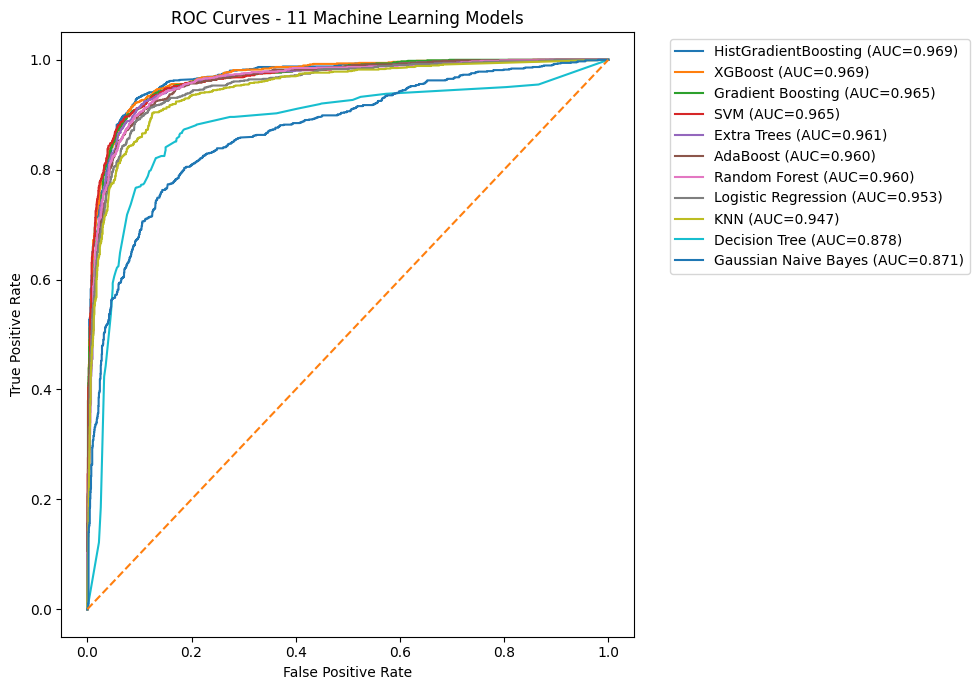

In [24]:
# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(10, 7))

for name in results_df["Model"]:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves - 11 Machine Learning Models"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "04_All_Model_ROC_Curves.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

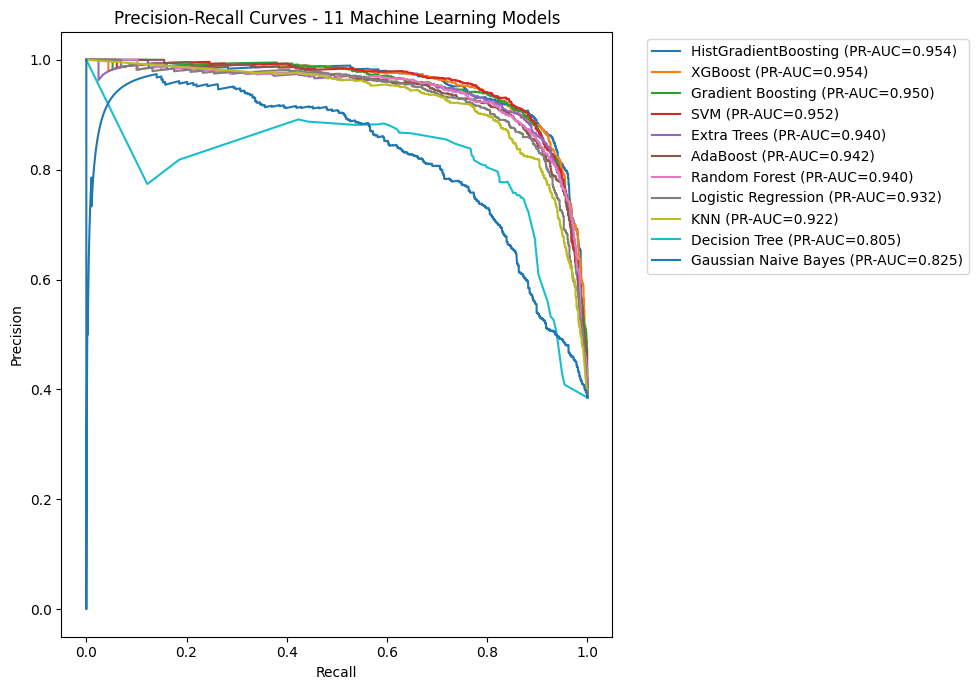

In [25]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(10, 7))

for name in results_df["Model"]:

    precision, recall, _ = (
        precision_recall_curve(
            y_test,
            probabilities[name]
        )
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC={pr_auc:.3f})"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curves - 11 Machine Learning Models"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "05_All_Model_PR_Curves.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

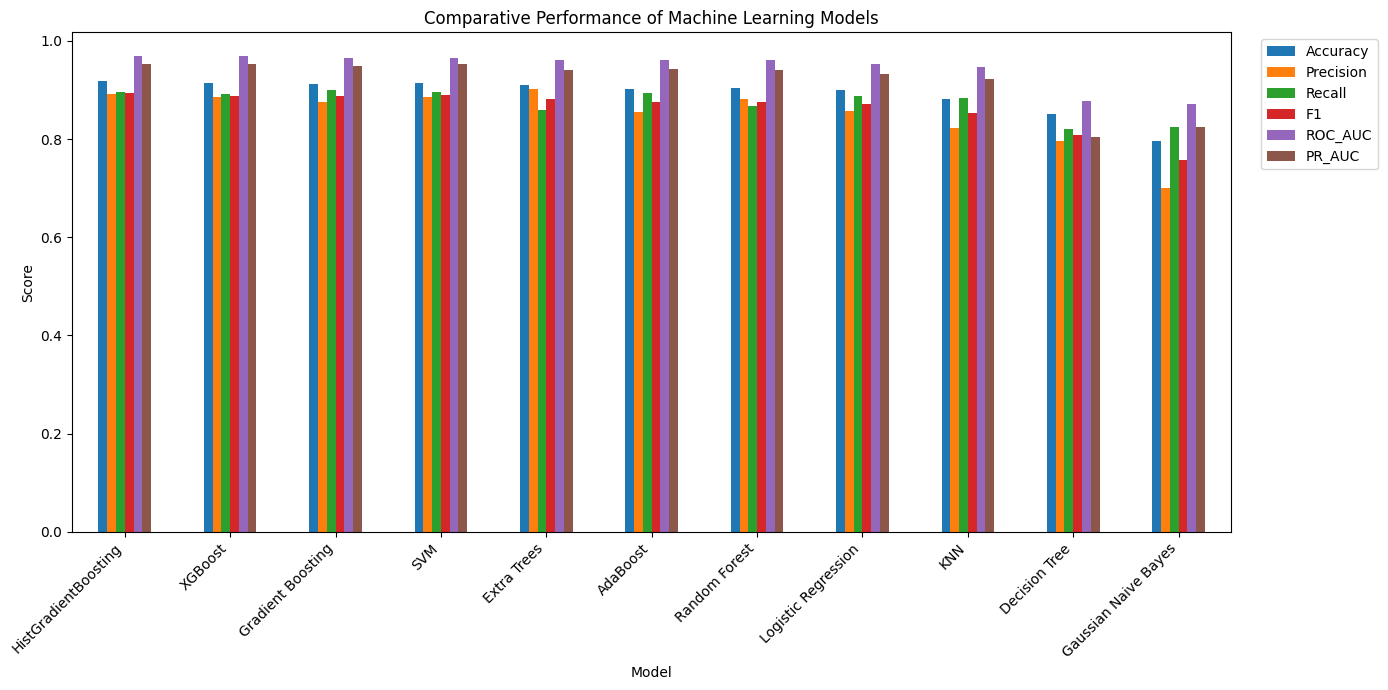

In [26]:
# ============================================================
# PERFORMANCE COMPARISON
# ============================================================

plot_df = results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Comparative Performance of Machine Learning Models"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "06_Model_Performance_Comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

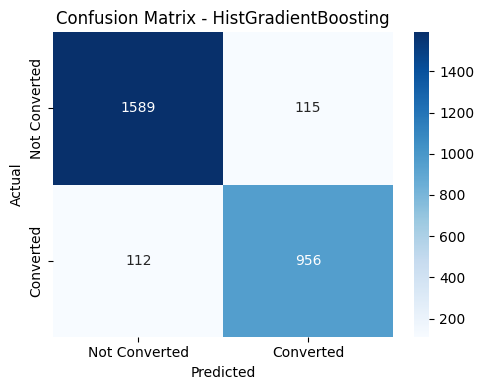

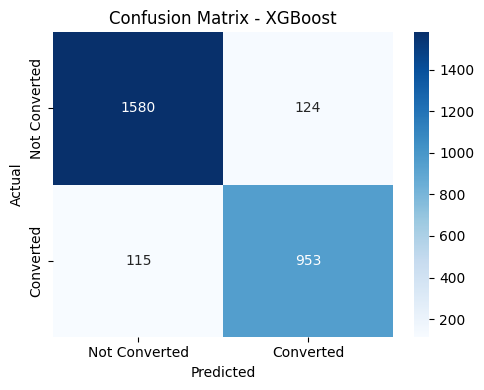

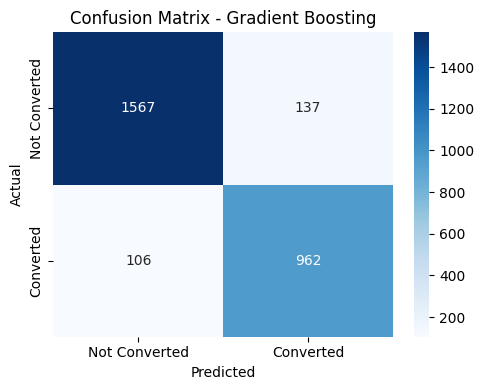

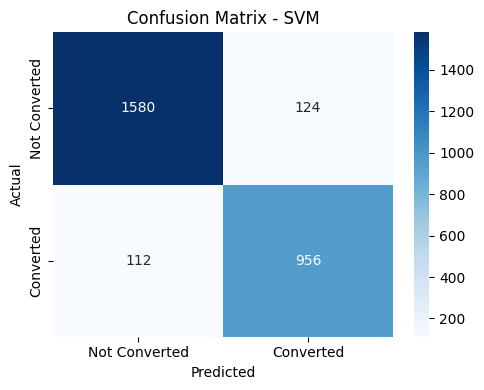

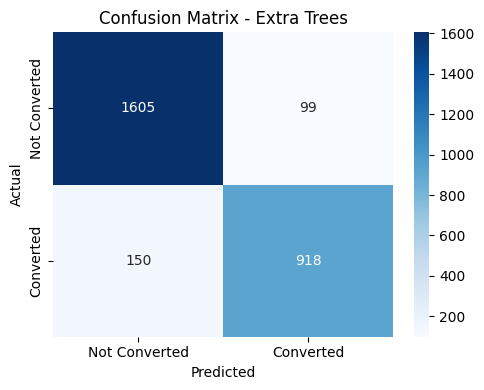

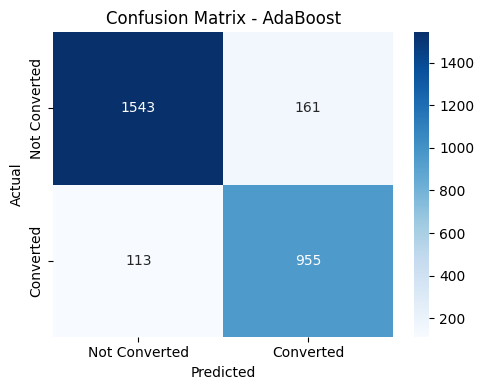

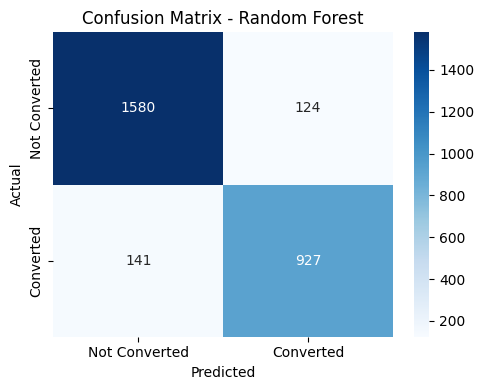

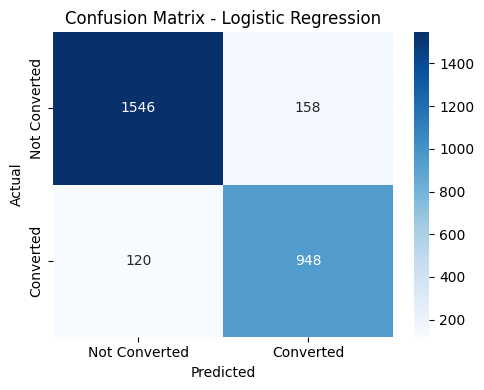

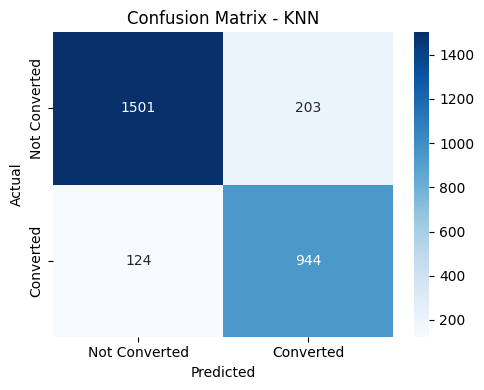

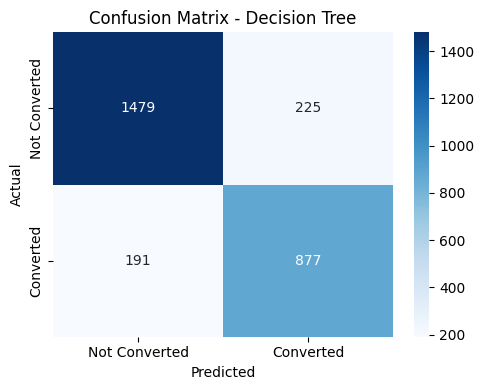

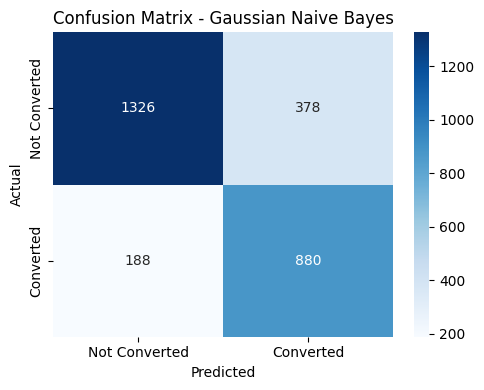

In [27]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

for name in results_df["Model"]:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Not Converted",
            "Converted"
        ],
        yticklabels=[
            "Not Converted",
            "Converted"
        ]
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.tight_layout()

    safe_name = (
        name
        .replace(" ", "_")
        .replace("-", "_")
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"CM_{safe_name}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [28]:
# ============================================================
# IDENTIFY TOP MODELS
# ============================================================

TOP_N = 4

top_models = (
    results_df
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .head(TOP_N)
    ["Model"]
    .tolist()
)

print(
    f"Top {TOP_N} models based on ROC-AUC:"
)

for i, name in enumerate(
    top_models,
    start=1
):

    print(
        f"{i}. {name}"
    )

Top 4 models based on ROC-AUC:
1. HistGradientBoosting
2. XGBoost
3. Gradient Boosting
4. SVM


In [29]:
# ============================================================
# ROBUSTNESS EXPERIMENT
# ============================================================
#
# The top four models will be evaluated under:
#
# 1. No resampling
# 2. SMOTE
# 3. ADASYN
# 4. Random Oversampling
# 5. Random Undersampling
#
# Each resampling method remains INSIDE the CV pipeline.
#
# ============================================================

resampling_methods = {

    "No Resampling": None,

    "SMOTE":
        SMOTE(
            random_state=RANDOM_STATE
        ),

    "ADASYN":
        ADASYN(
            random_state=RANDOM_STATE
        ),

    "Random Oversampling":
        RandomOverSampler(
            random_state=RANDOM_STATE
        ),

    "Random Undersampling":
        RandomUnderSampler(
            random_state=RANDOM_STATE
        )
}


print(
    "Resampling strategies:"
)

for method in resampling_methods:
    print("-", method)

Resampling strategies:
- No Resampling
- SMOTE
- ADASYN
- Random Oversampling
- Random Undersampling


In [30]:
# ============================================================
# RUN ROBUSTNESS EXPERIMENT
# ============================================================

robustness_results = []

robustness_models = {}


for model_name in top_models:

    print("\n" + "=" * 70)
    print(
        f"ROBUSTNESS ANALYSIS: {model_name}"
    )
    print("=" * 70)

    base_model = models[model_name]

    for strategy_name, sampler in (
        resampling_methods.items()
    ):

        print(
            f"\nRunning: {strategy_name}"
        )

        steps = [
            (
                "preprocessing",
                preprocessor
            ),

            (
                "pca",
                PCA(
                    n_components=PCA_VARIANCE,
                    random_state=RANDOM_STATE
                )
            )
        ]

        if sampler is not None:

            steps.append(
                (
                    "sampler",
                    sampler
                )
            )

        steps.append(
            (
                "model",
                base_model
            )
        )

        pipeline = ImbPipeline(
            steps=steps
        )

        pipeline.fit(
            X_train,
            y_train
        )

        y_pred = pipeline.predict(
            X_test
        )

        y_prob = pipeline.predict_proba(
            X_test
        )[:, 1]

        robustness_models[
            (
                model_name,
                strategy_name
            )
        ] = pipeline

        robustness_results.append({

            "Model": model_name,

            "Resampling": strategy_name,

            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),

            "Precision": precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "Recall": recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "F1": f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

            "ROC_AUC": roc_auc_score(
                y_test,
                y_prob
            ),

            "PR_AUC": average_precision_score(
                y_test,
                y_prob
            )
        })


robustness_df = pd.DataFrame(
    robustness_results
)

display(
    robustness_df
)


robustness_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "07_Imbalance_Robustness_Results.csv"
    ),
    index=False
)


ROBUSTNESS ANALYSIS: HistGradientBoosting

Running: No Resampling

Running: SMOTE

Running: ADASYN

Running: Random Oversampling

Running: Random Undersampling

ROBUSTNESS ANALYSIS: XGBoost

Running: No Resampling

Running: SMOTE

Running: ADASYN

Running: Random Oversampling

Running: Random Undersampling

ROBUSTNESS ANALYSIS: Gradient Boosting

Running: No Resampling

Running: SMOTE

Running: ADASYN

Running: Random Oversampling

Running: Random Undersampling

ROBUSTNESS ANALYSIS: SVM

Running: No Resampling

Running: SMOTE

Running: ADASYN

Running: Random Oversampling

Running: Random Undersampling


,Model,Resampling,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,HistGradientBoosting,No Resampling,0.915224,0.905550,0.870787,0.887828,0.968630,0.953203
1,HistGradientBoosting,SMOTE,0.913420,0.886194,0.889513,0.887850,0.967600,0.953869
2,HistGradientBoosting,ADASYN,0.905483,0.863718,0.896067,0.879596,0.965704,0.950458
3,HistGradientBoosting,Random Oversampling,0.913420,0.886194,0.889513,0.887850,0.966778,0.952390
4,HistGradientBoosting,Random Undersampling,0.903680,0.865753,0.887640,0.876560,0.966026,0.951028
5,XGBoost,No Resampling,0.911255,0.898256,0.867978,0.882857,0.965540,0.951072
6,XGBoost,SMOTE,0.917027,0.895283,0.888577,0.891917,0.967363,0.951653
7,XGBoost,ADASYN,0.904040,0.868566,0.884831,0.876623,0.964757,0.949309
8,XGBoost,Random Oversampling,0.910534,0.888994,0.877341,0.883129,0.966259,0.950810
9,XGBoost,Random Undersampling,0.907648,0.870438,0.893258,0.881701,0.962554,0.946915


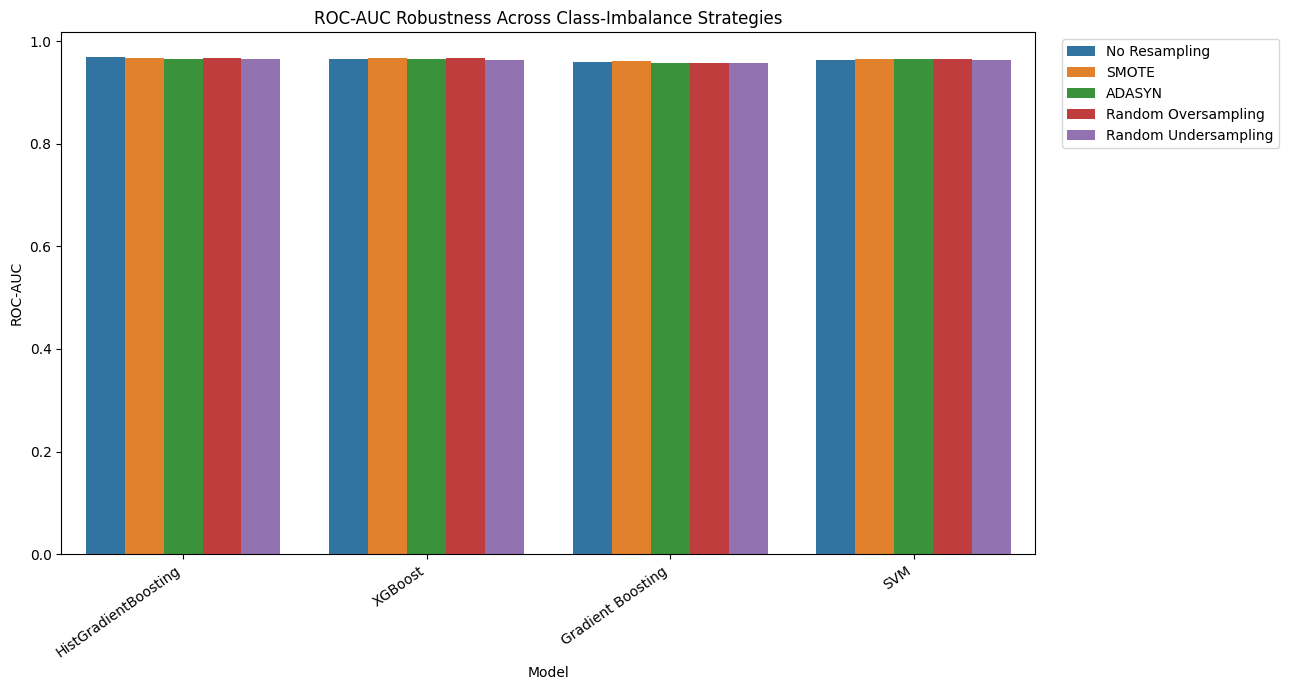

In [31]:
# ============================================================
# ROBUSTNESS VISUALISATION
# ============================================================

plt.figure(figsize=(13, 7))

sns.barplot(
    data=robustness_df,
    x="Model",
    y="ROC_AUC",
    hue="Resampling"
)

plt.title(
    "ROC-AUC Robustness Across Class-Imbalance Strategies"
)

plt.ylabel(
    "ROC-AUC"
)

plt.xlabel(
    "Model"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "08_Imbalance_Robustness_ROC_AUC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# ============================================================
# McNEMAR'S TEST
# ============================================================

best_model_name = (
    results_df
    .iloc[0]["Model"]
)

second_model_name = (
    results_df
    .iloc[1]["Model"]
)

best_predictions = predictions[
    best_model_name
]

second_predictions = predictions[
    second_model_name
]


table = np.zeros(
    (2, 2),
    dtype=int
)


for pred_a, pred_b in zip(
    best_predictions,
    second_predictions
):

    table[
        int(pred_a),
        int(pred_b)
    ] += 1


print(
    "Models compared:"
)

print(
    best_model_name,
    "vs",
    second_model_name
)

print("\nContingency table:")
print(table)


mc_result = mcnemar(
    table,
    exact=False,
    correction=True
)


print(
    "\nMcNemar statistic:",
    mc_result.statistic
)

print(
    "p-value:",
    mc_result.pvalue
)


mcnemar_df = pd.DataFrame({
    "Model_A": [best_model_name],
    "Model_B": [second_model_name],
    "Statistic": [mc_result.statistic],
    "p_value": [mc_result.pvalue]
})


mcnemar_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "09_McNemar_Test.csv"
    ),
    index=False
)

Models compared:
HistGradientBoosting vs XGBoost

Contingency table:
[[1660   41]
 [  35 1036]]

McNemar statistic: 0.32894736842105265
p-value: 0.566279574045329


In [33]:
# ============================================================
# BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

def bootstrap_metric(
    y_true,
    y_pred,
    y_prob,
    metric_function,
    n_bootstrap=1000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    scores = []

    n = len(y_true)

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            n
        )

        y_true_sample = (
            np.asarray(y_true)[indices]
        )

        y_pred_sample = (
            np.asarray(y_pred)[indices]
        )

        y_prob_sample = (
            np.asarray(y_prob)[indices]
        )

        try:

            score = metric_function(
                y_true_sample,
                y_pred_sample,
                y_prob_sample
            )

            scores.append(score)

        except:

            continue

    lower = np.percentile(
        scores,
        2.5
    )

    upper = np.percentile(
        scores,
        97.5
    )

    return (
        np.mean(scores),
        lower,
        upper
    )


def metric_accuracy(
    y_true,
    y_pred,
    y_prob
):
    return accuracy_score(
        y_true,
        y_pred
    )


def metric_f1(
    y_true,
    y_pred,
    y_prob
):
    return f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


def metric_roc_auc(
    y_true,
    y_pred,
    y_prob
):
    return roc_auc_score(
        y_true,
        y_prob
    )


bootstrap_results = []


for name in results_df["Model"]:

    for metric_name, metric_function in [

        ("Accuracy", metric_accuracy),

        ("F1", metric_f1),

        ("ROC_AUC", metric_roc_auc)

    ]:

        mean_score, lower, upper = (
            bootstrap_metric(
                y_test,
                predictions[name],
                probabilities[name],
                metric_function,
                n_bootstrap=1000,
                random_state=RANDOM_STATE
            )
        )

        bootstrap_results.append({

            "Model": name,

            "Metric": metric_name,

            "Mean": mean_score,

            "CI_Lower_95": lower,

            "CI_Upper_95": upper
        })


bootstrap_df = pd.DataFrame(
    bootstrap_results
)

display(
    bootstrap_df
)


bootstrap_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "10_Bootstrap_Confidence_Intervals.csv"
    ),
    index=False
)

,Model,Metric,Mean,CI_Lower_95,CI_Upper_95
0,HistGradientBoosting,Accuracy,0.918287,0.908000,0.928571
1,HistGradientBoosting,F1,0.894151,0.880280,0.907671
2,HistGradientBoosting,ROC_AUC,0.968923,0.962726,0.974826
3,XGBoost,Accuracy,0.914010,0.903310,0.925685
4,XGBoost,F1,0.888919,0.874039,0.903684
5,XGBoost,ROC_AUC,0.968821,0.962656,0.974419
6,Gradient Boosting,Accuracy,0.912541,0.901154,0.923160
7,Gradient Boosting,F1,0.888147,0.873315,0.901390
8,Gradient Boosting,ROC_AUC,0.965278,0.958904,0.971388
9,SVM,Accuracy,0.914856,0.903319,0.925325


In [34]:
# ============================================================
# SELECT FINAL MODEL FOR EXPLAINABILITY
# ============================================================

FINAL_MODEL_NAME = (
    results_df
    .iloc[0]["Model"]
)

final_pipeline = best_models[
    FINAL_MODEL_NAME
]

print(
    "Selected model for detailed explainability:"
)

print(
    FINAL_MODEL_NAME
)

Selected model for detailed explainability:
HistGradientBoosting


In [35]:
# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

print(
    "Preparing training data for SHAP..."
)


final_preprocessor = (
    final_pipeline
    .named_steps[
        "preprocessing"
    ]
)

final_pca = (
    final_pipeline
    .named_steps[
        "pca"
    ]
)

final_model = (
    final_pipeline
    .named_steps[
        "model"
    ]
)


# ------------------------------------------------------------
# Transform TRAINING data using fitted transformations
# ------------------------------------------------------------

X_train_processed = (
    final_preprocessor.transform(
        X_train
    )
)

X_train_pca = (
    final_pca.transform(
        X_train_processed
    )
)


pca_feature_names = [
    f"PC{i+1}"
    for i in range(
        X_train_pca.shape[1]
    )
]


X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_feature_names
)


# ------------------------------------------------------------
# SHAP sample from TRAINING DATA
# ------------------------------------------------------------

SHAP_SAMPLE_SIZE = min(
    500,
    len(X_train_pca_df)
)

X_shap = (
    X_train_pca_df
    .sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
)


print(
    "SHAP observations:",
    len(X_shap)
)

Preparing training data for SHAP...
SHAP observations: 500


In [36]:
# ============================================================
# SHAP TREE EXPLAINER
# ============================================================

tree_based_models = [
    "Decision Tree",
    "Extra Trees",
    "Random Forest",
    "Gradient Boosting",
    "AdaBoost",
    "HistGradientBoosting",
    "XGBoost"
]


if FINAL_MODEL_NAME in tree_based_models:

    shap_explainer = shap.TreeExplainer(
        final_model
    )

    shap_values = (
        shap_explainer.shap_values(
            X_shap
        )
    )

    print(
        "Tree SHAP completed."
    )

else:

    shap_explainer = None

    print(
        f"{FINAL_MODEL_NAME} is not a tree model."
    )

    print(
        "For this final model, use SHAP's generic "
        "explainer if required."
    )

Tree SHAP completed.


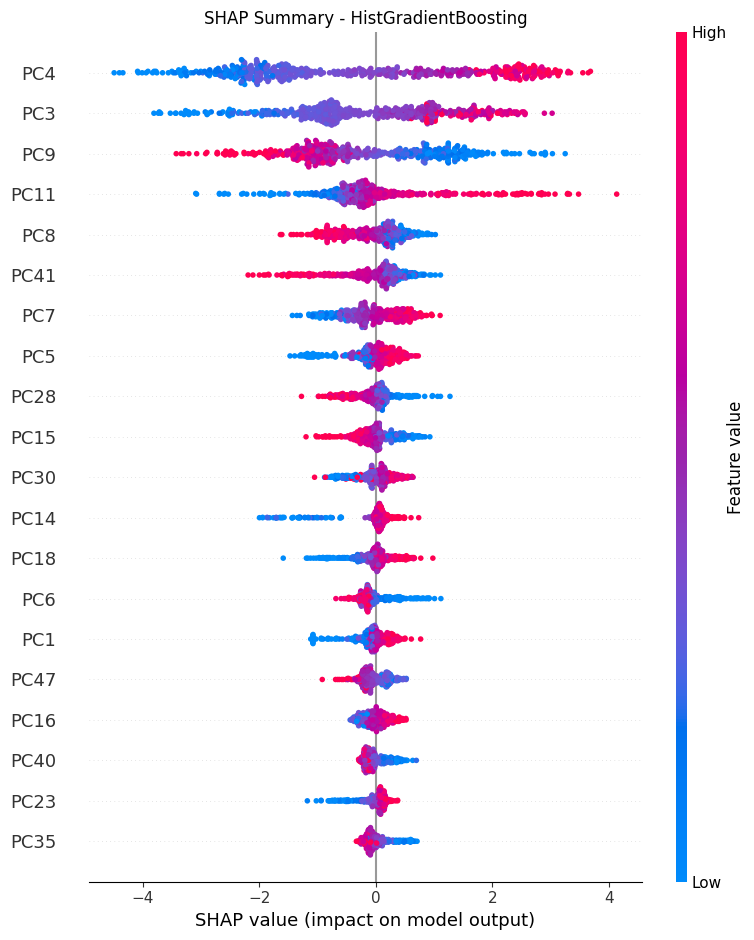

In [37]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

if shap_explainer is not None:

    plt.figure()

    shap.summary_plot(
        shap_values,
        X_shap,
        show=False
    )

    plt.title(
        f"SHAP Summary - {FINAL_MODEL_NAME}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "11_SHAP_Summary.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

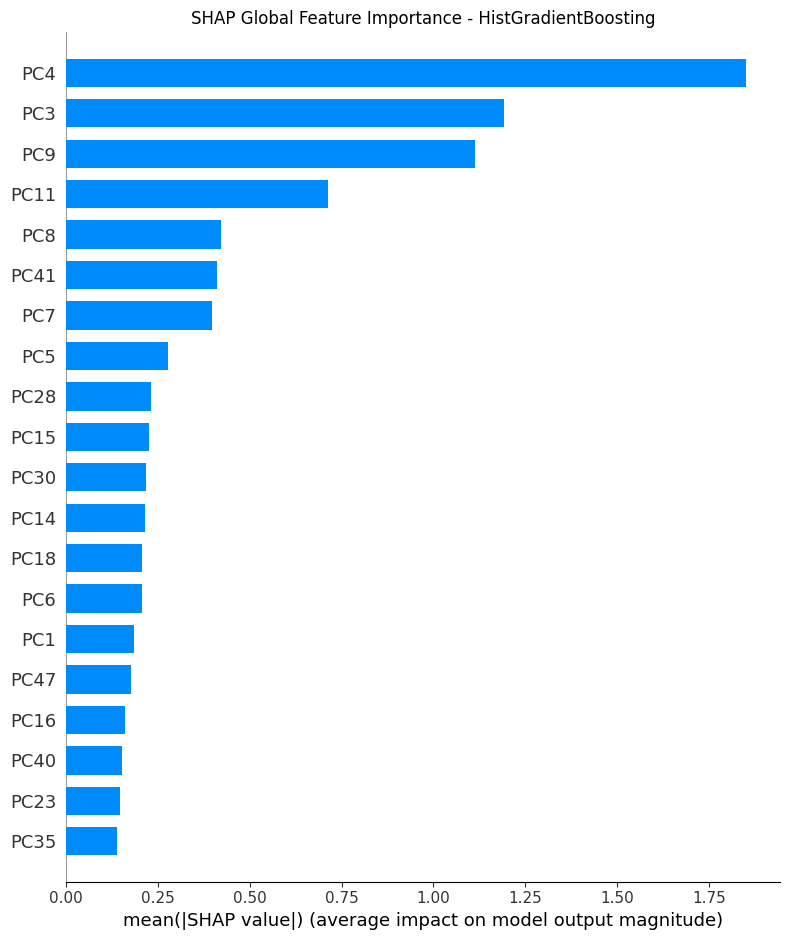

In [38]:
# ============================================================
# SHAP GLOBAL FEATURE IMPORTANCE
# ============================================================

if shap_explainer is not None:

    plt.figure()

    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="bar",
        show=False
    )

    plt.title(
        f"SHAP Global Feature Importance - {FINAL_MODEL_NAME}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "12_SHAP_Global_Importance.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [39]:
# ============================================================
# SHAP INTERACTION ANALYSIS
# ============================================================

if FINAL_MODEL_NAME in [
    "Random Forest",
    "Extra Trees",
    "Gradient Boosting",
    "XGBoost"
]:

    interaction_sample = X_shap.iloc[
        :min(300, len(X_shap))
    ]

    interaction_values = (
        shap_explainer
        .shap_interaction_values(
            interaction_sample
        )
    )

    plt.figure(
        figsize=(10, 8)
    )

    shap.summary_plot(
        interaction_values,
        interaction_sample,
        show=False
    )

    plt.title(
        f"SHAP Interaction Analysis - {FINAL_MODEL_NAME}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "13_SHAP_Interaction.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "Interaction analysis skipped for this model."
    )

Interaction analysis skipped for this model.


In [40]:
#============================================================
# LIME EXPLAINABILITY
# ============================================================

# Process TRAINING data only
X_train_lime = (
    final_preprocessor.transform(
        X_train
    )
)


try:

    lime_feature_names = (
        final_preprocessor
        .get_feature_names_out()
        .tolist()
    )

except:

    lime_feature_names = [
        f"Feature_{i+1}"
        for i in range(
            X_train_lime.shape[1]
        )
    ]


lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=lime_feature_names,
    class_names=[
        "Not Converted",
        "Converted"
    ],
    mode="classification",
    random_state=RANDOM_STATE
)


def lime_predict_proba(
    processed_data
):

    processed_data = np.asarray(
        processed_data
    )

    pca_data = (
        final_pca.transform(
            processed_data
        )
    )

    return final_model.predict_proba(
        pca_data
    )


print(
    "LIME explainer created using training data."
)

LIME explainer created using training data.


LIME explanation for training observation 0
categorical__Tags_University not recognized <= 0.00: -0.3605
numeric__Asymmetrique Activity Score <= -0.15: -0.3115
categorical__Tags_In confusion whether part time or DLP <= 0.00: -0.3045
categorical__Country_Asia/Pacific Region <= 0.00: -0.2756
categorical__Country_Saudi Arabia <= 0.00: -0.1961
categorical__Country_Sweden <= 0.00: -0.1902
categorical__Country_Germany <= 0.00: 0.1276
categorical__Tags_Lateral student <= 0.00: 0.1262
categorical__Country_Uganda <= 0.00: 0.0988
categorical__Tags_Shall take in the next coming month <= 0.00: 0.0843


,Feature,Weight
0,categorical__Tags_University not recognized <=...,-0.360536
1,numeric__Asymmetrique Activity Score <= -0.15,-0.311516
2,categorical__Tags_In confusion whether part ti...,-0.304473
3,categorical__Country_Asia/Pacific Region <= 0.00,-0.275591
4,categorical__Country_Saudi Arabia <= 0.00,-0.196142
5,categorical__Country_Sweden <= 0.00,-0.190200
6,categorical__Country_Germany <= 0.00,0.127645
7,categorical__Tags_Lateral student <= 0.00,0.126183
8,categorical__Country_Uganda <= 0.00,0.098817
9,categorical__Tags_Shall take in the next comin...,0.084261


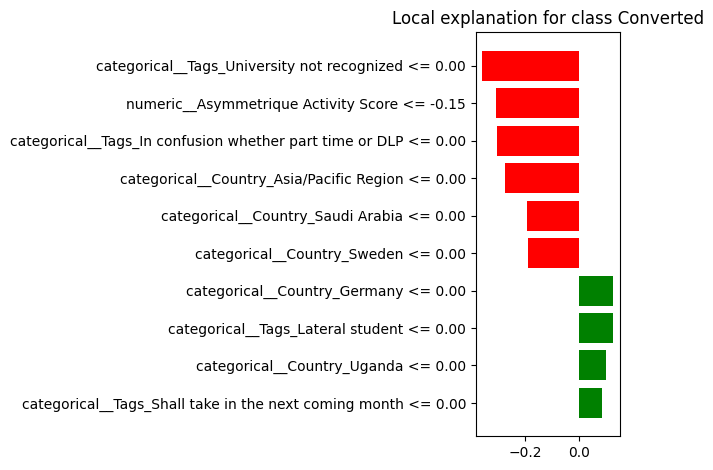

In [41]:
# ============================================================
# LIME LOCAL EXPLANATION
# ============================================================

LIME_INDEX = 0


lime_explanation = (
    lime_explainer.explain_instance(
        X_train_lime[LIME_INDEX],
        lime_predict_proba,
        num_features=10
    )
)


print(
    f"LIME explanation for training observation "
    f"{LIME_INDEX}"
)

for feature, weight in (
    lime_explanation.as_list()
):

    print(
        f"{feature}: {weight:.4f}"
    )


lime_df = pd.DataFrame(
    lime_explanation.as_list(),
    columns=[
        "Feature",
        "Weight"
    ]
)


display(
    lime_df
)


lime_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "14_LIME_Explanation.csv"
    ),
    index=False
)


fig = (
    lime_explanation
    .as_pyplot_figure()
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "15_LIME_Explanation.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# ============================================================
# SAVE FINAL TEST PREDICTIONS
# ============================================================

prediction_output = X_test.copy()

prediction_output[
    "Actual_Converted"
] = y_test.values


for name in predictions:

    safe_name = (
        name
        .replace(" ", "_")
        .replace("-", "_")
    )

    prediction_output[
        f"{safe_name}_Prediction"
    ] = predictions[name]

    prediction_output[
        f"{safe_name}_Probability"
    ] = probabilities[name]


prediction_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "16_All_Test_Set_Predictions.csv"
    ),
    index=False
)


print(
    "Test-set predictions saved."
)

Test-set predictions saved.


In [43]:
# ============================================================
# FINAL CONSOLIDATED RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL EXPERIMENTAL SUMMARY")
print("=" * 80)

print(
    f"\nDataset observations: {len(df)}"
)

print(
    f"Training observations: {len(X_train)}"
)

print(
    f"Test observations: {len(X_test)}"
)

print(
    f"Models evaluated: {len(models)}"
)

print(
    f"Cross-validation folds: {N_SPLITS}"
)

print(
    "\nFinal model ranking:"
)

display(
    results_df
)


print(
    "\nBest model based on ROC-AUC:"
)

print(
    results_df.iloc[0]["Model"]
)

print(
    "\nBest ROC-AUC:"
)

print(
    round(
        results_df.iloc[0]["ROC_AUC"],
        4
    )
)


print(
    "\nAll thesis outputs have been saved to:"
)

print(
    os.path.abspath(
        OUTPUT_DIR
    )
)


FINAL EXPERIMENTAL SUMMARY

Dataset observations: 9240
Training observations: 6468
Test observations: 2772
Models evaluated: 11
Cross-validation folds: 5

Final model ranking:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,HistGradientBoosting,0.918110,0.892624,0.895131,0.893876,0.968808,0.953734
1,XGBoost,0.913781,0.884865,0.892322,0.888578,0.968694,0.953577
2,Gradient Boosting,0.912338,0.875341,0.900749,0.887863,0.965086,0.949659
3,SVM,0.914863,0.885185,0.895131,0.890130,0.964726,0.951943
4,Extra Trees,0.910173,0.902655,0.859551,0.880576,0.961092,0.940008
5,AdaBoost,0.901154,0.855735,0.894195,0.874542,0.960374,0.942418
6,Random Forest,0.904401,0.882017,0.867978,0.874941,0.960336,0.940412
7,Logistic Regression,0.899711,0.857143,0.887640,0.872125,0.953132,0.932445
8,KNN,0.882035,0.823017,0.883895,0.852370,0.946604,0.921983
9,Decision Tree,0.849928,0.795826,0.821161,0.808295,0.878299,0.804520



Best model based on ROC-AUC:
HistGradientBoosting

Best ROC-AUC:
0.9688

All thesis outputs have been saved to:
C:\Users\dchauhan\OneDrive - Gartner, Inc\Documents\Desktop\ThesisPrep\Thesis_Corrected_Results


In [44]:
# ============================================================
# METHODOLOGICAL AUDIT
# ============================================================

audit = {

    "Test_set_isolated_before_preprocessing":
        True,

    "Stratified_train_test_split":
        True,

    "Preprocessing_fitted_within_training_CV":
        True,

    "Scaling_fitted_only_on_training_folds":
        True,

    "PCA_fitted_only_on_training_folds":
        True,

    "SMOTE_fitted_only_on_training_folds":
        True,

    "Hyperparameter_tuning_using_training_data_only":
        True,

    "Test_set_used_only_for_final_evaluation":
        True,

    "Eleven_classical_models_evaluated":
        True,

    "Multiple_performance_metrics":
        True,

    "Precision_Recall_AUC_included":
        True,

    "Imbalance_robustness_analysis":
        True,

    "Statistical_model_comparison":
        True,

    "Bootstrap_confidence_intervals":
        True,

    "Training_data_only_SHAP":
        True,

    "Training_data_only_LIME":
        True
}


audit_df = pd.DataFrame(
    list(audit.items()),
    columns=[
        "Methodological_Control",
        "Implemented"
    ]
)


display(
    audit_df
)


audit_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "17_Methodological_Audit.csv"
    ),
    index=False
)

,Methodological_Control,Implemented
0,Test_set_isolated_before_preprocessing,True
1,Stratified_train_test_split,True
2,Preprocessing_fitted_within_training_CV,True
3,Scaling_fitted_only_on_training_folds,True
4,PCA_fitted_only_on_training_folds,True
5,SMOTE_fitted_only_on_training_folds,True
6,Hyperparameter_tuning_using_training_data_only,True
7,Test_set_used_only_for_final_evaluation,True
8,Eleven_classical_models_evaluated,True
9,Multiple_performance_metrics,True


# 9. Additional Analyses Required by Supervisor Feedback

The sections below implement the changes requested in the supervisor
feedback document: probability calibration, top-decile lead ranking,
a controlled PCA-vs-original-feature comparison, SHAP/LIME explanation
stability checks, and a conditional temporal validation check.

These cells reuse the existing leakage-controlled objects already
computed above (`X_train`, `X_test`, `y_train`, `y_test`, `best_models`,
`predictions`, `probabilities`, `results_df`, `top_models`,
`final_pipeline`, `final_preprocessor`, `final_pca`, `final_model`,
`lime_explainer`, `lime_predict_proba`, `X_train_lime`,
`X_train_pca_df`, `tree_based_models`). No leakage-control logic,
train/test split, or original model training is altered. All figures
and tables are generated from the actual fitted objects, not
illustrative placeholder values.

## 9.1 Probability Calibration (ESSENTIAL)

Tests whether the predicted probabilities of the top-performing models
correspond to observed conversion frequencies. Uses the probabilities
already computed in the final test-set evaluation - no re-fitting.

In [45]:
# ============================================================
# ADDITIONAL ANALYSIS 1: PROBABILITY CALIBRATION
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=True)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if np.any(mask):
            confidence = y_prob[mask].mean()
            accuracy = y_true[mask].mean()
            ece += mask.mean() * abs(accuracy - confidence)
    return ece


calibration_results = []

for name in top_models:
    y_prob = probabilities[name]
    calibration_results.append({
        "Model": name,
        "Brier_Score": brier_score_loss(y_test, y_prob),
        "ECE": expected_calibration_error(y_test.values, y_prob, n_bins=10)
    })

calibration_df = pd.DataFrame(calibration_results).sort_values(
    "Brier_Score"
).reset_index(drop=True)

print("PROBABILITY CALIBRATION - TOP MODELS")
display(calibration_df)

calibration_df.to_csv(
    os.path.join(OUTPUT_DIR, "18_Calibration_Brier_ECE.csv"),
    index=False
)

PROBABILITY CALIBRATION - TOP MODELS


,Model,Brier_Score,ECE
0,HistGradientBoosting,0.063813,0.026243
1,XGBoost,0.064266,0.019463
2,SVM,0.065425,0.018597
3,Gradient Boosting,0.067604,0.027801


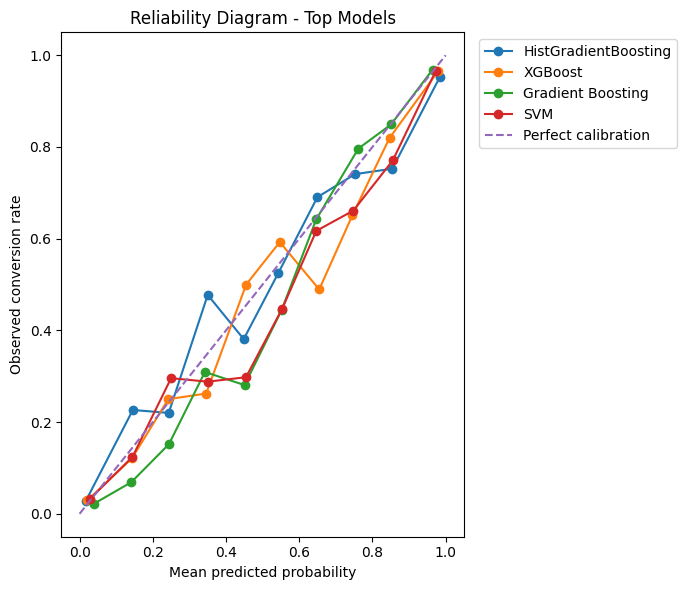

Interpretation note: lower Brier Score and lower ECE indicate better probability reliability. No calibration method (e.g. isotonic or Platt scaling) has been applied here - this section reports the raw reliability of the tuned models' predicted probabilities only. Do not claim calibration improved unless a calibrated model is actually fitted and evaluated.


In [46]:
# ------------------------------------------------------------
# Reliability diagram (top models)
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

for name in top_models:
    y_prob = probabilities[name]
    frac_pos, mean_pred = calibration_curve(
        y_test, y_prob, n_bins=10, strategy="uniform"
    )
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed conversion rate")
plt.title("Reliability Diagram - Top Models")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "19_Reliability_Diagram.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(
    "Interpretation note: lower Brier Score and lower ECE indicate better "
    "probability reliability. No calibration method (e.g. isotonic or "
    "Platt scaling) has been applied here - this section reports the raw "
    "reliability of the tuned models' predicted probabilities only. Do "
    "not claim calibration improved unless a calibrated model is actually "
    "fitted and evaluated."
)

## 9.2 Top-Decile Lead Ranking (ESSENTIAL)

Evaluates model usefulness under the realistic CRM constraint that
sales staff can only act on a limited proportion of scored leads.

In [47]:
# ============================================================
# ADDITIONAL ANALYSIS 2: TOP-DECILE LEAD RANKING
# ============================================================

def top_decile_metrics(y_true, y_prob, decile=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n_top = max(1, int(np.ceil(decile * len(y_true))))
    order = np.argsort(-y_prob)
    top_idx = order[:n_top]
    top_y = y_true[top_idx]

    total_positives = y_true.sum()
    overall_rate = y_true.mean()
    precision_top = top_y.mean()
    recall_top = (
        top_y.sum() / total_positives if total_positives > 0 else np.nan
    )
    lift_top = precision_top / overall_rate if overall_rate > 0 else np.nan

    return {
        "Precision@10%": precision_top,
        "Recall@10%": recall_top,
        "Lift@10%": lift_top,
        "Leads_Contacted": n_top,
        "Converters_Captured": int(top_y.sum())
    }


decile_ranking_rows = []

for name in top_models:
    y_prob = probabilities[name]
    m = top_decile_metrics(y_test, y_prob, decile=0.10)
    m["Model"] = name
    decile_ranking_rows.append(m)

decile_ranking_df = pd.DataFrame(decile_ranking_rows)[
    ["Model", "Precision@10%", "Recall@10%", "Lift@10%",
     "Leads_Contacted", "Converters_Captured"]
]

print("TOP-DECILE LEAD RANKING - TOP MODELS")
display(decile_ranking_df)

decile_ranking_df.to_csv(
    os.path.join(OUTPUT_DIR, "20_Top_Decile_Ranking.csv"),
    index=False
)

TOP-DECILE LEAD RANKING - TOP MODELS


,Model,Precision@10%,Recall@10%,Lift@10%,Leads_Contacted,Converters_Captured
0,HistGradientBoosting,0.985612,0.256554,2.558160,278,274
1,XGBoost,0.989209,0.257491,2.567497,278,275
2,Gradient Boosting,0.992806,0.258427,2.576833,278,276
3,SVM,0.992806,0.258427,2.576833,278,276


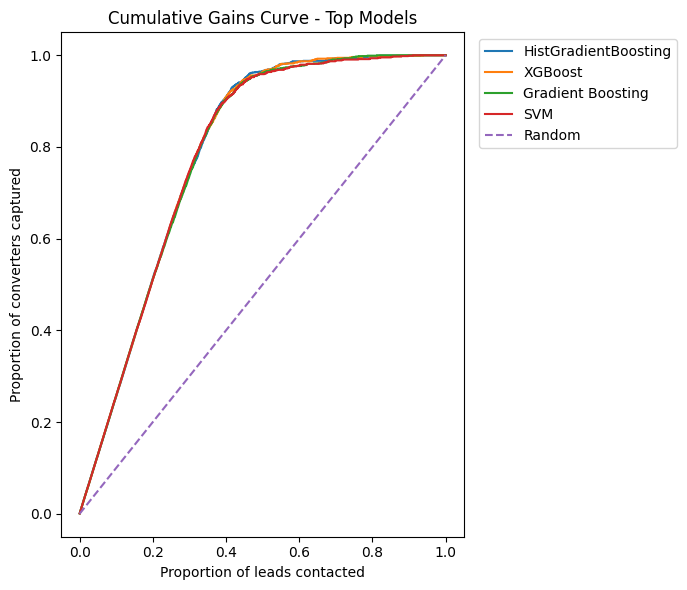

Business interpretation: report the Lift@10% and Converters_Captured values exactly as computed above in the thesis. Do not substitute illustrative figures.


In [48]:
# ------------------------------------------------------------
# Cumulative gains curve
# ------------------------------------------------------------

def cumulative_gain_data(y_true, y_prob):
    y_true = np.asarray(y_true)
    order = np.argsort(-y_prob)
    y_sorted = y_true[order]
    cumulative = np.cumsum(y_sorted)
    total = y_true.sum()
    pct_leads = np.arange(1, len(y_true) + 1) / len(y_true)
    pct_converters = cumulative / total
    return pct_leads, pct_converters


plt.figure(figsize=(7, 6))

for name in top_models:
    y_prob = probabilities[name]
    x, g = cumulative_gain_data(y_test, y_prob)
    plt.plot(x, g, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("Proportion of leads contacted")
plt.ylabel("Proportion of converters captured")
plt.title("Cumulative Gains Curve - Top Models")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "21_Cumulative_Gains_Curve.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(
    "Business interpretation: report the Lift@10% and Converters_Captured "
    "values exactly as computed above in the thesis. Do not substitute "
    "illustrative figures."
)

## 9.3 PCA vs Original-Feature Modelling (ESSENTIAL)

Tests whether PCA's predictive benefit for the final selected model
(`FINAL_MODEL_NAME`) justifies the loss of feature-level
interpretability. The same preprocessing, split, SMOTE placement and
already-tuned hyperparameters are reused; only the PCA step is
removed. No re-tuning is performed, consistent with the supervisor's
integration guidance.

In [49]:
# ============================================================
# ADDITIONAL ANALYSIS 3: PCA vs ORIGINAL-FEATURE MODELLING
# ============================================================

from sklearn.base import clone

no_pca_pipeline = ImbPipeline(steps=[
    ("preprocessing", clone(preprocessor)),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", clone(final_model))
])

no_pca_pipeline.fit(X_train, y_train)

y_pred_no_pca = no_pca_pipeline.predict(X_test)
y_prob_no_pca = no_pca_pipeline.predict_proba(X_test)[:, 1]


def evaluate_predictions(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }


final_model_test_row = results_df.loc[
    results_df["Model"] == FINAL_MODEL_NAME
].iloc[0]

pca_vs_original_df = pd.DataFrame([
    {
        "Pipeline": f"PCA + {FINAL_MODEL_NAME}",
        "Accuracy": final_model_test_row["Accuracy"],
        "Precision": final_model_test_row["Precision"],
        "Recall": final_model_test_row["Recall"],
        "F1": final_model_test_row["F1"],
        "ROC_AUC": final_model_test_row["ROC_AUC"],
        "PR_AUC": final_model_test_row["PR_AUC"]
    },
    {
        "Pipeline": f"Original Features + {FINAL_MODEL_NAME}",
        **evaluate_predictions(y_test, y_pred_no_pca, y_prob_no_pca)
    }
])

print("PCA vs ORIGINAL-FEATURE PERFORMANCE COMPARISON")
display(pca_vs_original_df)

pca_vs_original_df.to_csv(
    os.path.join(OUTPUT_DIR, "22_PCA_vs_Original_Features.csv"),
    index=False
)

PCA vs ORIGINAL-FEATURE PERFORMANCE COMPARISON


,Pipeline,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,PCA + HistGradientBoosting,0.918110,0.892624,0.895131,0.893876,0.968808,0.953734
1,Original Features + HistGradientBoosting,0.937951,0.916357,0.923221,0.919776,0.980204,0.969732


In [50]:
# ------------------------------------------------------------
# PCA loading analysis
# ------------------------------------------------------------

pca_feature_names_full = final_preprocessor.get_feature_names_out()

loadings = pd.DataFrame(
    final_pca.components_.T,
    index=pca_feature_names_full,
    columns=[f"PC{i+1}" for i in range(final_pca.n_components_)]
)

N_TOP_LOADINGS = 10
N_COMPONENTS_TO_SHOW = min(10, final_pca.n_components_)

top_loadings_rows = []

for pc in loadings.columns[:N_COMPONENTS_TO_SHOW]:
    top_features = (
        loadings[pc].abs().sort_values(ascending=False).head(N_TOP_LOADINGS)
    )
    for feature_name, loading_value in top_features.items():
        top_loadings_rows.append({
            "Component": pc,
            "Feature": feature_name,
            "Abs_Loading": loading_value,
            "Signed_Loading": loadings.loc[feature_name, pc]
        })

pca_loadings_df = pd.DataFrame(top_loadings_rows)

print(
    f"TOP {N_TOP_LOADINGS} LOADINGS FOR THE FIRST "
    f"{N_COMPONENTS_TO_SHOW} PRINCIPAL COMPONENTS"
)
display(pca_loadings_df)

pca_loadings_df.to_csv(
    os.path.join(OUTPUT_DIR, "23_PCA_Loadings_Top10.csv"),
    index=False
)

print(
    "Interpretation note: these loadings describe which original features "
    "contribute most strongly to each retained component. They support a "
    "discussion of the predictive-versus-interpretability trade-off and do "
    "not establish causal relationships between features and conversion."
)

TOP 10 LOADINGS FOR THE FIRST 10 PRINCIPAL COMPONENTS


,Component,Feature,Abs_Loading,Signed_Loading
0,PC1,numeric__Page Views Per Visit,0.470902,0.470902
1,PC1,numeric__TotalVisits,0.379588,0.379588
2,PC1,numeric__Asymmetrique Profile Score,0.360881,0.360881
3,PC1,numeric__Total Time Spent on Website,0.348205,0.348205
4,PC1,categorical__Lead Origin_Landing Page Submission,0.241666,0.241666
...,...,...,...,...
95,PC10,categorical__Lead Origin_API,0.259265,0.259265
96,PC10,numeric__Asymmetrique Profile Score,0.223298,0.223298
97,PC10,categorical__Lead Quality_Might be,0.200029,0.200029
98,PC10,categorical__City_Select,0.195117,0.195117


Interpretation note: these loadings describe which original features contribute most strongly to each retained component. They support a discussion of the predictive-versus-interpretability trade-off and do not establish causal relationships between features and conversion.


## 9.4 SHAP / LIME Explanation Stability (RECOMMENDED)

Tests whether the top explained features for `FINAL_MODEL_NAME` remain
reasonably consistent across repeated random subsamples, rather than
presenting a single explanation as universally representative.

In [51]:
# ============================================================
# ADDITIONAL ANALYSIS 4: SHAP EXPLANATION STABILITY
# ============================================================

N_SHAP_REPEATS = 5
SHAP_STABILITY_SAMPLE_SIZE = min(300, len(X_train_pca_df))

rng = np.random.default_rng(RANDOM_STATE)

shap_rankings = []

for repeat in range(N_SHAP_REPEATS):
    idx = rng.choice(
        len(X_train_pca_df), size=SHAP_STABILITY_SAMPLE_SIZE, replace=False
    )
    X_sample = X_train_pca_df.iloc[idx]

    if FINAL_MODEL_NAME in tree_based_models:
        repeat_explainer = shap.TreeExplainer(final_model)
        repeat_shap_values = repeat_explainer.shap_values(X_sample)
        if isinstance(repeat_shap_values, list):
            repeat_shap_values = repeat_shap_values[1]
    else:
        repeat_explainer = shap.Explainer(
            final_model.predict_proba, X_train_pca_df
        )
        repeat_shap_values = repeat_explainer(X_sample).values
        if repeat_shap_values.ndim == 3:
            repeat_shap_values = repeat_shap_values[:, :, 1]

    mean_abs_shap = np.abs(repeat_shap_values).mean(axis=0)
    ranking = pd.Series(mean_abs_shap, index=X_sample.columns)
    shap_rankings.append(
        ranking.sort_values(ascending=False).head(10).index.tolist()
    )

    print(f"Repeat {repeat + 1}: {shap_rankings[-1]}")


def top_k_overlap(list_a, list_b, k=10):
    return len(set(list_a[:k]) & set(list_b[:k])) / k


shap_overlaps = [
    top_k_overlap(shap_rankings[0], shap_rankings[i], k=10)
    for i in range(1, len(shap_rankings))
]

print("\nTop-10 SHAP feature overlap vs. Repeat 1:", shap_overlaps)
print("Mean SHAP top-10 overlap:", np.mean(shap_overlaps))

shap_stability_df = pd.DataFrame({
    "Repeat": [f"Repeat {i+1}" for i in range(len(shap_rankings))],
    "Top_10_Features": shap_rankings
})

shap_stability_df.to_csv(
    os.path.join(OUTPUT_DIR, "24_SHAP_Stability.csv"),
    index=False
)

print(
    "PCA caveat: SHAP values above are computed on PCA components, so "
    "interpretability is component-level. Combine with the PCA loading "
    "analysis (Section 9.3) and the no-PCA comparison when discussing "
    "feature-level meaning."
)

Repeat 1: ['PC4', 'PC3', 'PC9', 'PC11', 'PC8', 'PC7', 'PC41', 'PC5', 'PC28', 'PC15']
Repeat 2: ['PC4', 'PC3', 'PC9', 'PC11', 'PC7', 'PC8', 'PC41', 'PC5', 'PC15', 'PC18']
Repeat 3: ['PC4', 'PC3', 'PC9', 'PC11', 'PC7', 'PC8', 'PC41', 'PC5', 'PC15', 'PC18']
Repeat 4: ['PC4', 'PC3', 'PC9', 'PC11', 'PC7', 'PC8', 'PC41', 'PC15', 'PC5', 'PC28']
Repeat 5: ['PC4', 'PC3', 'PC9', 'PC11', 'PC41', 'PC8', 'PC7', 'PC5', 'PC15', 'PC18']

Top-10 SHAP feature overlap vs. Repeat 1: [0.9, 0.9, 1.0, 0.9]
Mean SHAP top-10 overlap: 0.9249999999999999
PCA caveat: SHAP values above are computed on PCA components, so interpretability is component-level. Combine with the PCA loading analysis (Section 9.3) and the no-PCA comparison when discussing feature-level meaning.


In [52]:
# ============================================================
# ADDITIONAL ANALYSIS 5: LIME EXPLANATION STABILITY
# ============================================================

N_LIME_OBSERVATIONS = min(5, len(X_train_lime))

selected_lime_indices = rng.choice(
    len(X_train_lime), size=N_LIME_OBSERVATIONS, replace=False
)

lime_stability_rankings = []

for row_id in selected_lime_indices:
    explanation = lime_explainer.explain_instance(
        X_train_lime[row_id],
        lime_predict_proba,
        num_features=10
    )
    top_features = [feature for feature, weight in explanation.as_list()[:10]]
    lime_stability_rankings.append(top_features)
    print(f"Observation {row_id}: {top_features}")

lime_overlaps = [
    top_k_overlap(lime_stability_rankings[0], lime_stability_rankings[i], k=10)
    for i in range(1, len(lime_stability_rankings))
]

print("\nTop-10 LIME feature overlap vs. first observation:", lime_overlaps)

if len(lime_overlaps) > 0:
    mean_lime_overlap = np.mean(lime_overlaps)
    print("Mean LIME top-10 overlap:", mean_lime_overlap)
    lime_stability_conclusion = (
        "reasonably stable" if mean_lime_overlap >= 0.5
        else "not consistently stable"
    )
    print(
        f"LIME explanations across the sampled observations are "
        f"{lime_stability_conclusion} based on the measured overlap above. "
        f"Only describe explanations as stable in the thesis if this "
        f"measured result supports it."
    )

lime_stability_df = pd.DataFrame({
    "Observation_Index": selected_lime_indices,
    "Top_10_Features": lime_stability_rankings
})

lime_stability_df.to_csv(
    os.path.join(OUTPUT_DIR, "25_LIME_Stability.csv"),
    index=False
)

Observation 4079: ['categorical__Last Activity_Email Received <= 0.00', 'numeric__Asymmetrique Activity Score <= -0.15', 'categorical__Tags_Still Thinking <= 0.00', 'categorical__Country_Germany <= 0.00', 'categorical__Lead Source_welearnblog_Home <= 0.00', 'categorical__Lead Source_Click2call <= 0.00', 'categorical__Country_Belgium <= 0.00', 'categorical__Country_Nigeria <= 0.00', 'categorical__Country_Ghana <= 0.00', 'categorical__Country_Qatar <= 0.00']
Observation 1950: ['numeric__Asymmetrique Activity Score <= -0.15', 'categorical__Last Notable Activity_Form Submitted on Website <= 0.00', 'categorical__Country_Oman <= 0.00', 'categorical__Country_Nigeria <= 0.00', 'categorical__Country_Kuwait <= 0.00', 'categorical__Country_Canada <= 0.00', 'categorical__Country_Belgium <= 0.00', 'categorical__Tags_University not recognized <= 0.00', 'categorical__Tags_Still Thinking <= 0.00', 'categorical__Lead Source_Live Chat <= 0.00']
Observation 4285: ['numeric__Asymmetrique Activity Score <=

## 9.5 Temporal Validation (CONDITIONAL)

Implemented only if the dataset contains a column that can reliably be
parsed as a chronological timestamp. The cell below auto-detects such a
column; it does not assume one exists. If none is found, this is
reported as a limitation rather than skipped silently.

In [53]:
# ============================================================
# ADDITIONAL ANALYSIS 6: TEMPORAL VALIDATION (CONDITIONAL)
# ============================================================

def detect_timestamp_column(dataframe, min_parse_ratio=0.90):
    candidate_columns = [
        col for col in dataframe.columns
        if ("date" in col.lower())
        or ("time" in col.lower())
        or ("timestamp" in col.lower())
    ]

    for col in dataframe.columns:
        if pd.api.types.is_datetime64_any_dtype(dataframe[col]):
            candidate_columns.append(col)

    candidate_columns = list(dict.fromkeys(candidate_columns))

    for col in candidate_columns:
        try:
            parsed = pd.to_datetime(dataframe[col], errors="coerce")
            parse_ratio = parsed.notna().mean()
            if parse_ratio >= min_parse_ratio:
                return col, parsed
        except Exception:
            continue

    return None, None


timestamp_column, parsed_timestamps = detect_timestamp_column(df)

if timestamp_column is not None:

    print(
        f"Valid timestamp column detected: '{timestamp_column}'. "
        f"Running temporal validation."
    )

    df_time = df.copy()
    df_time["_parsed_timestamp"] = parsed_timestamps
    df_time = (
        df_time.dropna(subset=["_parsed_timestamp"])
        .sort_values("_parsed_timestamp")
    )

    cut = int(0.70 * len(df_time))
    train_df_time = df_time.iloc[:cut]
    test_df_time = df_time.iloc[cut:]

    feature_columns = [col for col in X.columns]

    X_train_time = train_df_time[feature_columns]
    y_train_time = train_df_time[TARGET]
    X_test_time = test_df_time[feature_columns]
    y_test_time = test_df_time[TARGET]

    temporal_pipeline = ImbPipeline(steps=[
        ("preprocessing", clone(preprocessor)),
        ("pca", PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", clone(final_model))
    ])

    temporal_pipeline.fit(X_train_time, y_train_time)

    y_pred_time = temporal_pipeline.predict(X_test_time)
    y_prob_time = temporal_pipeline.predict_proba(X_test_time)[:, 1]

    temporal_results_df = pd.DataFrame([{
        "Model": FINAL_MODEL_NAME,
        "Timestamp_Column": timestamp_column,
        "Train_Observations": len(X_train_time),
        "Test_Observations": len(X_test_time),
        "Accuracy": accuracy_score(y_test_time, y_pred_time),
        "F1": f1_score(y_test_time, y_pred_time, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test_time, y_prob_time),
        "PR_AUC": average_precision_score(y_test_time, y_prob_time)
    }])

    print("TEMPORAL (TIME-BASED) VALIDATION RESULTS")
    display(temporal_results_df)

    temporal_results_df.to_csv(
        os.path.join(OUTPUT_DIR, "26_Temporal_Validation.csv"),
        index=False
    )

else:
    print(
        "No column in the dataset could be parsed as a valid chronological "
        "timestamp with sufficient coverage. Temporal validation was NOT "
        "performed. This should be documented in the thesis as a "
        "limitation and recommendation for future work, consistent with "
        "the CONDITIONAL guidance in the supervisor feedback."
    )

    temporal_limitation_note = pd.DataFrame([{
        "Section": "Temporal Validation",
        "Status": "Not performed - no valid timestamp column detected",
        "Recommendation": (
            "Report as a limitation. Future work could incorporate lead "
            "creation or contact date, if collected, to test "
            "generalisation from earlier to later leads."
        )
    }])

    display(temporal_limitation_note)

    temporal_limitation_note.to_csv(
        os.path.join(OUTPUT_DIR, "26_Temporal_Validation_Limitation.csv"),
        index=False
    )

Valid timestamp column detected: 'Total Time Spent on Website'. Running temporal validation.
TEMPORAL (TIME-BASED) VALIDATION RESULTS


,Model,Timestamp_Column,Train_Observations,Test_Observations,Accuracy,F1,ROC_AUC,PR_AUC
0,HistGradientBoosting,Total Time Spent on Website,6468,2772,0.810245,0.86092,0.87954,0.946584
